--- 步骤 1/6: 准备工作完成 ---

--- 步骤 2/6: 数据加载与预处理 ---
数据预处理完成。

--- 步骤 3/6: 模型训练 ---
模型训练完成并已保存。

--- 步骤 4/6: SHAP分析 ---


100%|===================| 955/958 [01:32<00:00]          0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


SHAP 值计算完成。


 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 81% (9 of 11) |####################    

组合图已保存至: Plot\combined_shap_pdp_plot.png


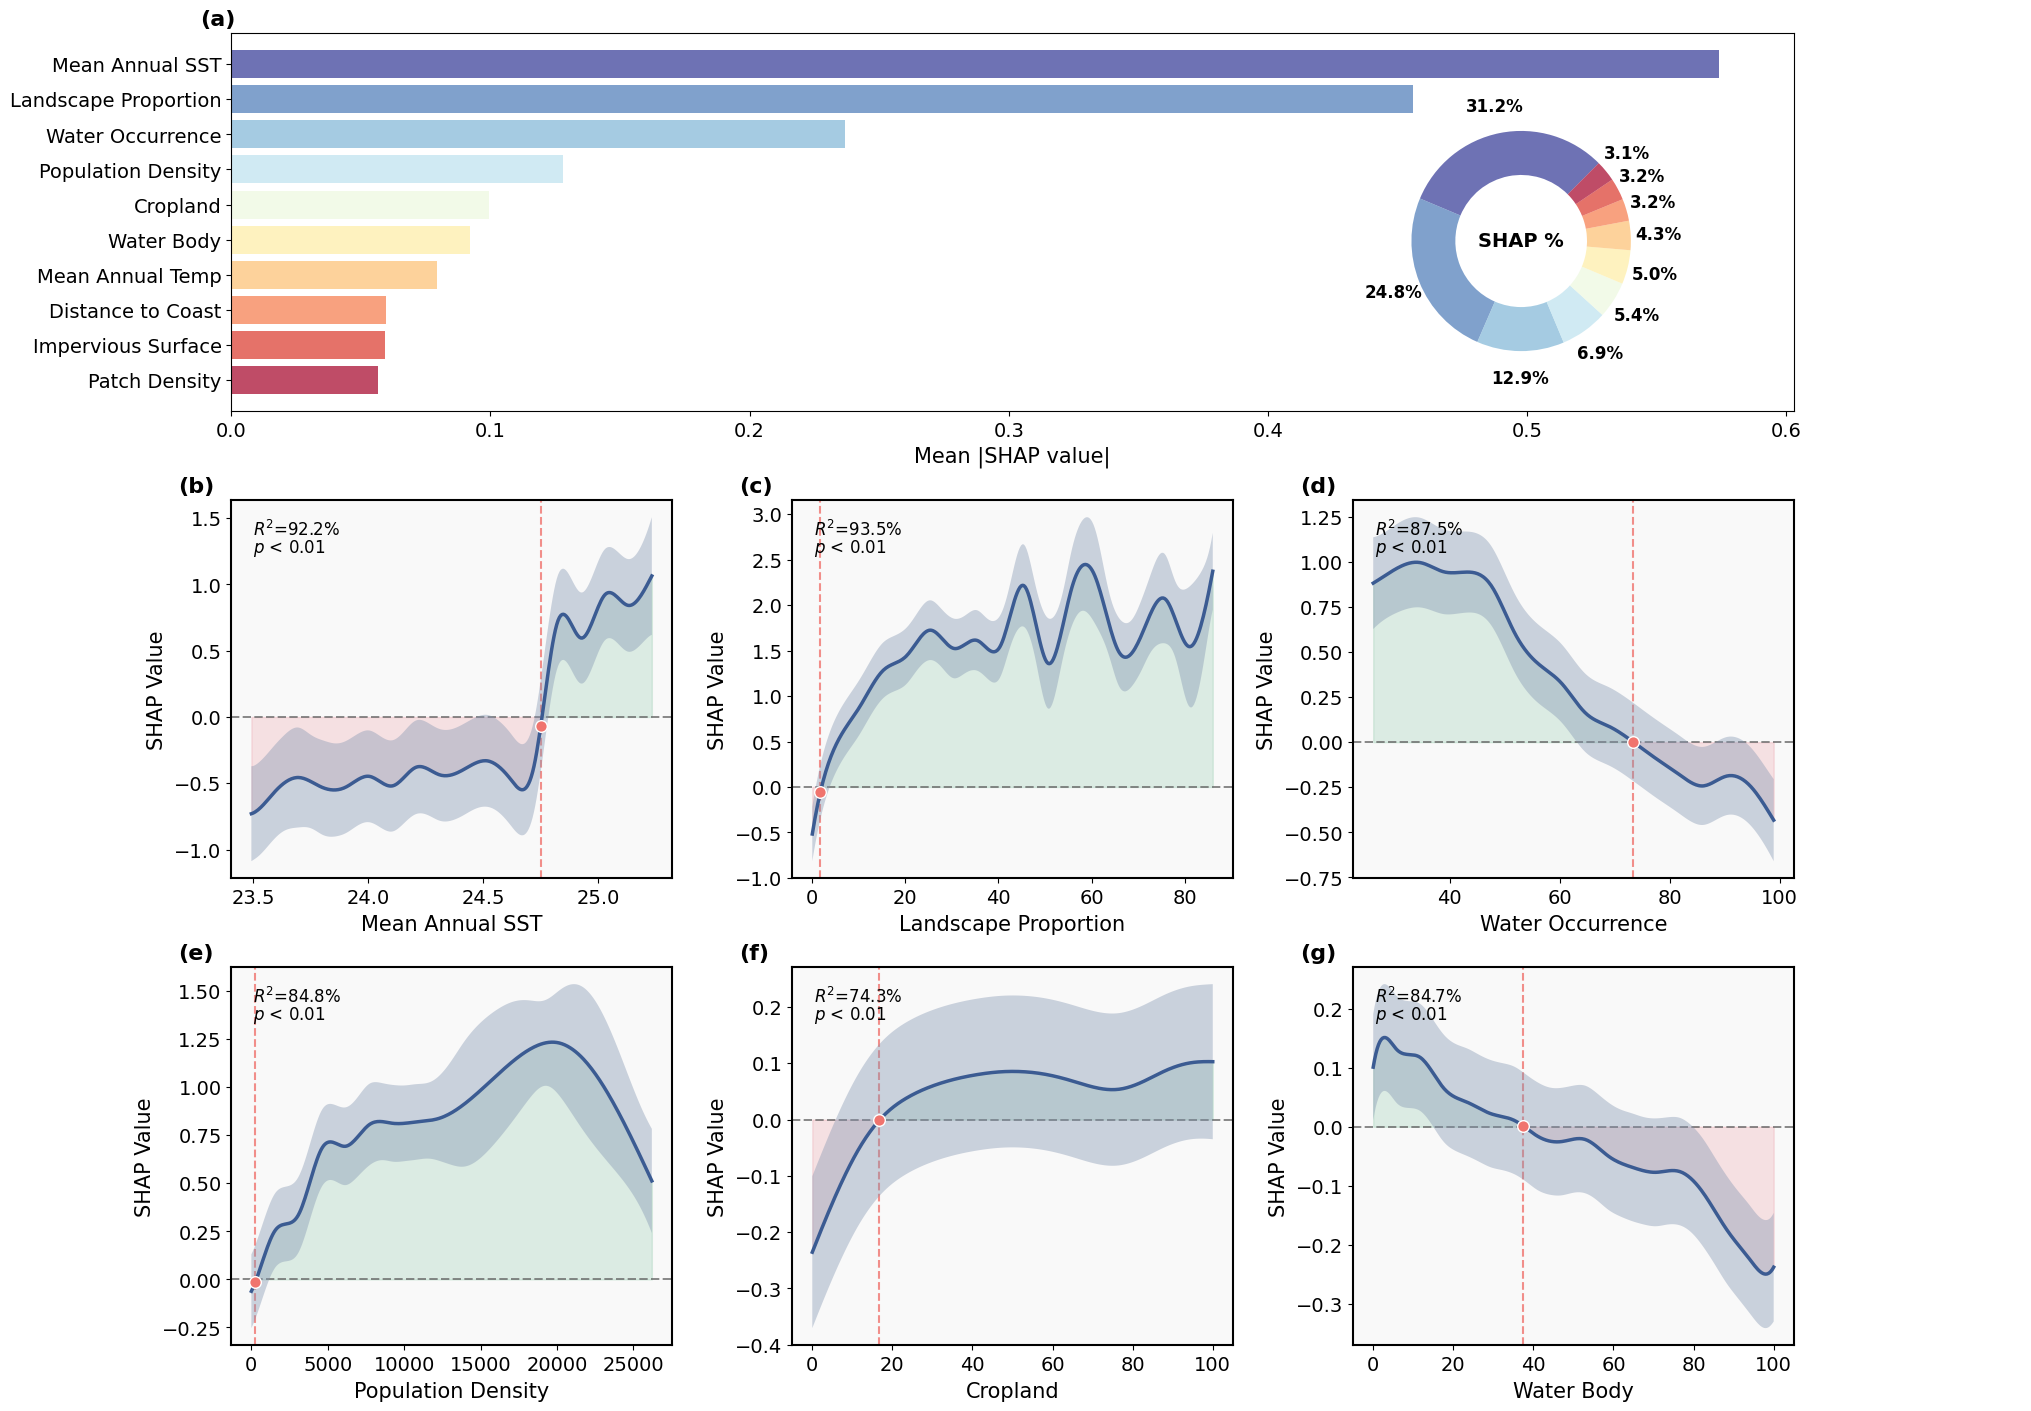

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
import shap
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import joblib
from pygam import LinearGAM, s
from matplotlib import rcParams
import os

# --- 1. 定义变量 ---
dependent_var = 'MHI'
independent_vars = [
    'cropland_percent', 
    #'forest_percent', 
    'impervious_surface_percent', 'water_percent',
    'ntl_mean', 'proportion_of_landscape', 'patch_density', 'edge_density',
    'mean_annual_temp', 'coldest_month_temp', 'total_annual_precip',
    'mean_annual_lst_day', 'mean_annual_sst', 'dist_to_coast',
    'water_occurrence', 'population_mean'
]
data_path = 'final_environment_with_MHI.csv'
output_model_path = 'rf_model.joblib'
output_combined_figure_path = r'Plot\combined_shap_pdp_plot.png'

print("--- 步骤 1/6: 准备工作完成 ---")

# --- 2. 数据加载与预处理 ---
print("\n--- 步骤 2/6: 数据加载与预处理 ---")
try:
    df = pd.read_csv(data_path)
    cols_to_keep = independent_vars + [dependent_var]
    df = df[cols_to_keep]
    df.dropna(subset=[dependent_var], inplace=True)
    X = df[independent_vars]
    y = df[dependent_var]
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X)
    X = pd.DataFrame(X_imputed, columns=independent_vars)
    print("数据预处理完成。")
except FileNotFoundError:
    print(f"错误: 数据文件未找到 '{data_path}'")
    exit()

# --- 3. 模型训练 ---
print("\n--- 步骤 3/6: 模型训练 ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
joblib.dump(rf_model, output_model_path)
print("模型训练完成并已保存。")

# --- 4. SHAP分析 ---
print("\n--- 步骤 4/6: SHAP分析 ---")
explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test, check_additivity=False)
print("SHAP 值计算完成。")

# --- 绘图函数定义 ---
# --- 变量重命名映射 ---
rename_dict = {
    'cropland_percent': 'Cropland',
    'impervious_surface_percent': 'Impervious Surface',
    'water_percent': 'Water Body',
    'ntl_mean': 'Nighttime Light',
    'proportion_of_landscape': 'Landscape Proportion',
    'patch_density': 'Patch Density',
    'edge_density': 'Edge Density',
    'mean_annual_temp': 'Mean Annual Temp',
    'coldest_month_temp': 'Min Temp of Coldest Month',
    'total_annual_precip': 'Annual Precipitation',
    'mean_annual_lst_day': 'Mean Annual LST Day',
    'mean_annual_sst': 'Mean Annual SST',
    'dist_to_coast': 'Distance to Coast',
    'water_occurrence': 'Water Occurrence',
    'population_mean': 'Population Density'
}

# --- 绘图函数定义 ---
def plot_shap_summary_custom(ax, shap_values, X_df):
    mean_shap_value = np.abs(shap_values.values).mean(0)
    # Apply renaming to column names
    labels = np.array([rename_dict.get(col, col) for col in X_df.columns])
    
    max_display = 10
    top_indices = np.argsort(mean_shap_value)[::-1][:max_display]
    sizes = mean_shap_value[top_indices]
    labels = labels[top_indices]
    
    cmap = plt.get_cmap("RdYlBu")
    colors = cmap(np.linspace(0, 1, len(sizes)))
    colors_corrected = colors[::-1]
    sizes_rev = sizes[::-1]
    labels_rev = labels[::-1]
    colors_rev = colors_corrected[::-1]

    ax.barh(range(len(sizes)), sizes_rev, color=colors_rev, alpha=0.7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels_rev, fontsize=15)
    ax.set_xlabel("Mean |SHAP value|", fontsize=15)
    ax.tick_params(axis='both', which='major', labelsize=14)
    # 修改后的饼图部分
    ax_inset = inset_axes(ax, width="80%", height="80%", loc='center right',
                          bbox_to_anchor=(0.35, 0.05, 0.8, 0.8), bbox_transform=ax.transAxes)
    wedges, texts, autotexts = ax_inset.pie(
        sizes,
        labels=None,
        autopct='%1.1f%%',
        startangle=45,
        colors=colors_corrected,
        wedgeprops=dict(width=0.4, alpha=0.7),
        textprops={'fontsize': 12},
        pctdistance=1.25
    )

    for autotext in autotexts:
        autotext.set_fontsize(12)
        autotext.set_weight("bold")

    # 将标题放在环形饼图圆心
    ax_inset.text(0, 0, "SHAP %", ha='center', va='center',
                  fontsize=14, fontweight="bold")
    ax_inset.axis('equal')
    return top_indices

def fit_enhanced_gam(X, y):
    return LinearGAM(s(0, n_splines=20, spline_order=3, lam=3)).gridsearch(X, y)

def plot_pdp_custom(ax, gam, X_feature, y_shap, feature_name):
    COLOR_PALETTE = {
        'main': '#3b5b92', 'ci': '#8395b1', 'positive': '#36a168',
        'negative': '#e05263', 'tipping_point': '#f0746e', 'background': '#f9f9f9', 'zero_line': '#666666'
    }
    ax.set_facecolor(COLOR_PALETTE['background'])
    XX = gam.generate_X_grid(term=0, n=300)
    y_pred = gam.predict(XX)
    ci = gam.prediction_intervals(XX, width=0.95)
    
    ax.axhline(0, color=COLOR_PALETTE['zero_line'], linestyle=(0, (5, 2)), linewidth=1.2, alpha=0.9, zorder=2)
    ax.fill_between(XX.flatten(), ci[:, 0], ci[:, 1], color=COLOR_PALETTE['ci'], alpha=0.4, zorder=3, edgecolor='none')
    ax.plot(XX, y_pred, color=COLOR_PALETTE['main'], linewidth=2.5, zorder=5)
    
    zero_crossings = np.where(np.diff(np.sign(y_pred)))[0]
    tipping_points = [(XX[i][0], y_pred[i]) for i in zero_crossings if i < len(XX)]
    if tipping_points:
        for x, y_tip in tipping_points:
            ax.axvline(x, color=COLOR_PALETTE['tipping_point'], linestyle='--', linewidth=1.5, alpha=0.8)
            ax.scatter(x, y_tip, color=COLOR_PALETTE['tipping_point'], s=70, zorder=6, edgecolor='white', linewidth=1)

    pos_mask = y_pred > 0
    if any(pos_mask): ax.fill_between(XX.flatten(), 0, y_pred, where=pos_mask, color=COLOR_PALETTE['positive'], alpha=0.15, zorder=0)
    neg_mask = y_pred <= 0
    if any(neg_mask): ax.fill_between(XX.flatten(), 0, y_pred, where=neg_mask, color=COLOR_PALETTE['negative'], alpha=0.15, zorder=0)
    
    ax.set_xlabel(feature_name, fontsize=15, labelpad=5)
    ax.set_ylabel('SHAP Value', fontsize=15,labelpad=5)
    ax.tick_params(axis='both', which='major', labelsize=14)
    for spine in ax.spines.values(): spine.set_linewidth(1.5)
    
    p_value = gam.statistics_['p_values'][0]
    p_text = f"$p$ < 0.01" if p_value < 0.01 else f"p = {p_value:.2e}"
    ax.text(0.05, 0.90, p_text, transform=ax.transAxes, ha='left', va='top', fontsize=12)
    R_squared = gam.statistics_['pseudo_r2']['explained_deviance'] * 100
    ax.text(0.05, 0.95, f"$R^2$={R_squared:.1f}%", transform=ax.transAxes, ha='left', va='top', fontsize=12)

num_pdp_plots = 6  # 改为6个PDP图
fig = plt.figure(figsize=(18, 14), constrained_layout=True)  
gs = GridSpec(3, 3, figure=fig, height_ratios=[1, 1, 1])  # 3行3列

# SHAP摘要图 - 占据第一行的全部3列
ax_shap = fig.add_subplot(gs[0, :])  # gs[0, :] 表示第0行,所有列
top_indices = plot_shap_summary_custom(ax_shap, shap_values, X_test)
ax_shap.text(-0.02, 1.02, '(a)', transform=ax_shap.transAxes, size=16, weight='bold')

# PDP图 - 第2-3行,每行3列,共6个
pdp_axes = [
    fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2]),  # 第2行
    fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]), fig.add_subplot(gs[2, 2])   # 第3行
]

top_feature_names = [X_test.columns[i] for i in top_indices]

for i, feature in enumerate(top_feature_names[:num_pdp_plots]):
    ax = pdp_axes[i]
    feature_index = list(X_test.columns).index(feature)
    X_feature = X_test[feature].values.reshape(-1, 1)
    y_shap = shap_values.values[:, feature_index].reshape(-1, 1)
    
    gam = fit_enhanced_gam(X_feature, y_shap)
    
    # 获取用于显示的特征名
    feature_display_name = rename_dict.get(feature, feature)
    
    plot_pdp_custom(ax, gam, X_feature, y_shap, feature_display_name)
    ax.text(-0.12, 1.02, f'({chr(98+i)})', transform=ax.transAxes, size=16, weight='bold')

plt.savefig(output_combined_figure_path, dpi=600)
print(f"组合图已保存至: {output_combined_figure_path}")
plt.show()



PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


ALE figure saved to: Plot\ale_top6_features.png


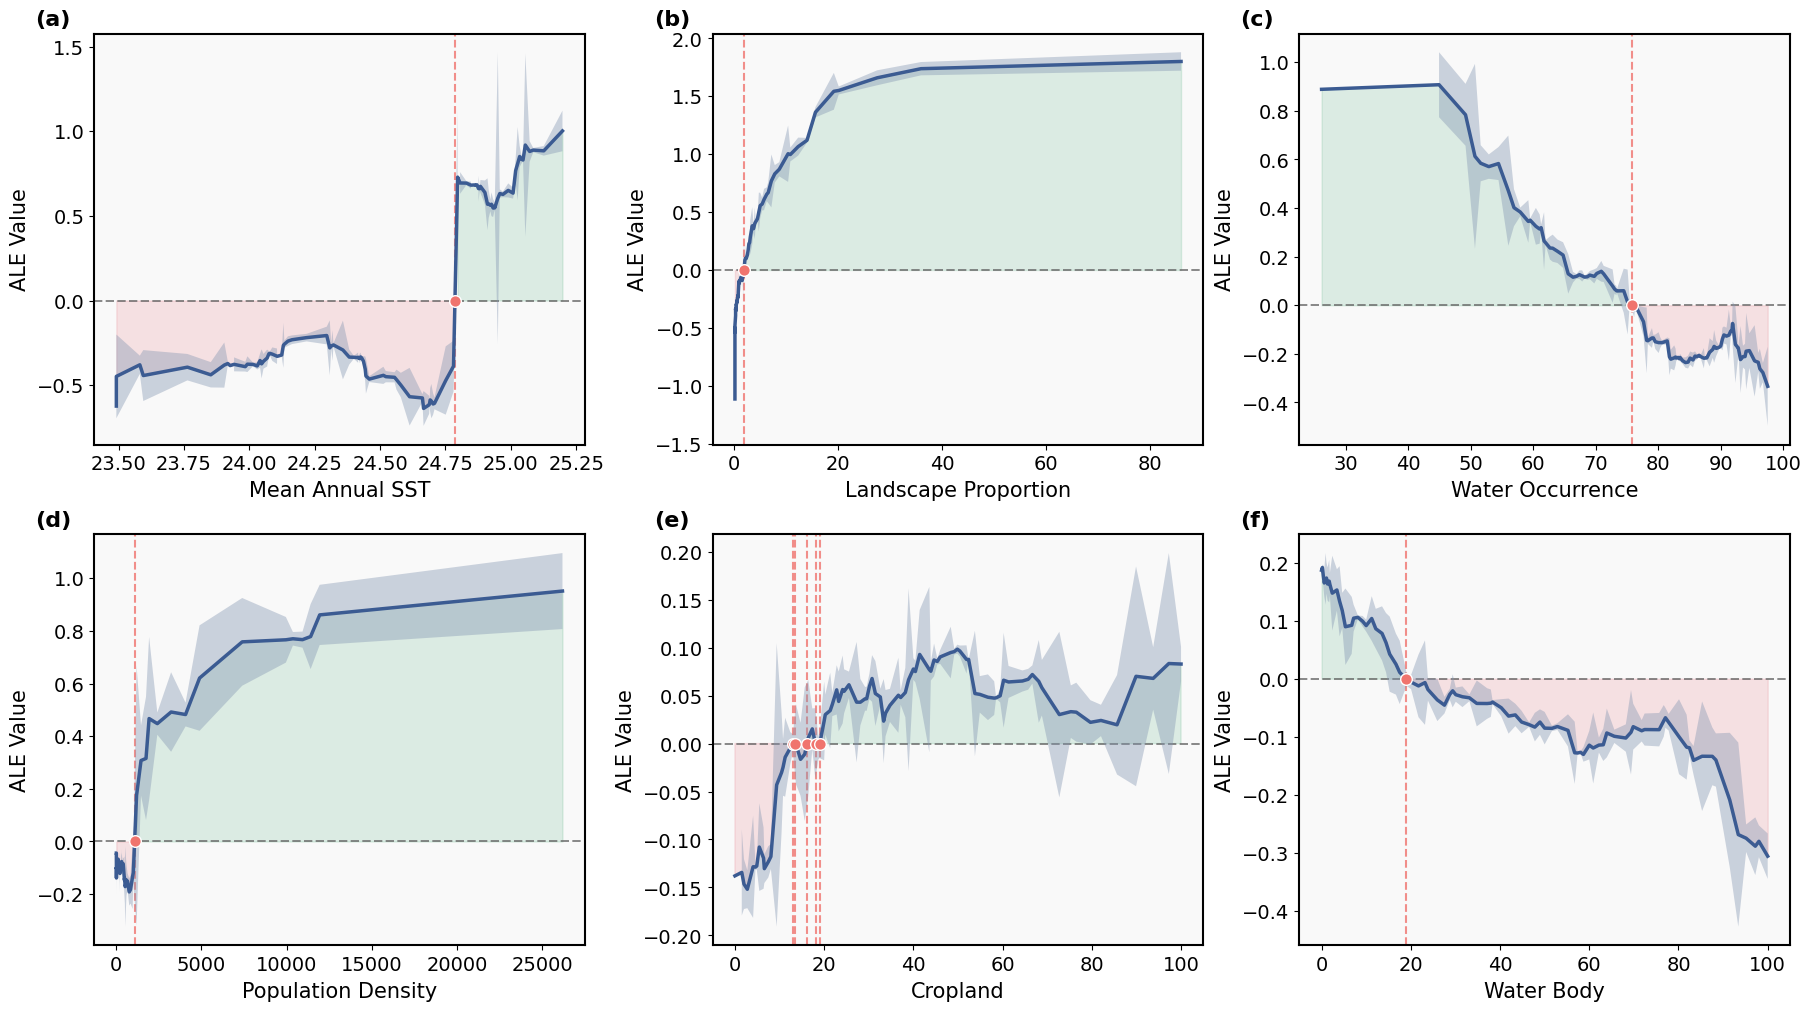

In [4]:
# --- 5. ALE analysis for top 6 SHAP features ---
# This cell expects rf_model, X_test, top_feature_names, and rename_dict from Cell 1.

from PyALE import ale
import numpy as np
import matplotlib.pyplot as plt

ALE_COLOR_PALETTE = {
    'main': '#3b5b92',
    'ci': '#8395b1',
    'positive': '#36a168',
    'negative': '#e05263',
    'tipping_point': '#f0746e',
    'background': '#f9f9f9',
    'zero_line': '#666666'
}

if "rf_model" not in globals() or "X_test" not in globals():
    raise RuntimeError("Please run Cell 1 first to get rf_model and X_test.")
if "top_feature_names" not in globals():
    raise RuntimeError("Please run Cell 1 first to get top_feature_names.")

sample_size = min(400, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=42).copy()
features_for_ale = list(top_feature_names[:6])

def _find_column(columns, include_keywords):
    for col in columns:
        col_lower = col.lower()
        if all(k in col_lower for k in include_keywords):
            return col
    return None

def _extract_ale_series(ale_df):
    cols = list(ale_df.columns)

    eff_col = None
    for candidate in ("eff", "ale", "ale_eff"):
        if candidate in cols:
            eff_col = candidate
            break
    if eff_col is None:
        for col in cols:
            col_lower = col.lower()
            if "eff" in col_lower or "ale" in col_lower:
                eff_col = col
                break
    if eff_col is None:
        raise ValueError(f"Unable to find ALE effect column in: {cols}")

    lower_col = _find_column(cols, ["lower"])
    upper_col = _find_column(cols, ["upper"])

    x_vals = np.asarray(ale_df.index.values, dtype=float)
    y_vals = np.asarray(ale_df[eff_col].values, dtype=float)
    lower_vals = np.asarray(ale_df[lower_col].values, dtype=float) if lower_col else None
    upper_vals = np.asarray(ale_df[upper_col].values, dtype=float) if upper_col else None
    return x_vals, y_vals, lower_vals, upper_vals

def plot_ale_custom(ax, x_vals, y_vals, lower_vals, upper_vals, feature_name):
    ax.set_facecolor(ALE_COLOR_PALETTE['background'])
    ax.axhline(0, color=ALE_COLOR_PALETTE['zero_line'], linestyle=(0, (5, 2)), linewidth=1.2, alpha=0.9, zorder=2)

    if lower_vals is not None and upper_vals is not None:
        ax.fill_between(
            x_vals,
            lower_vals,
            upper_vals,
            color=ALE_COLOR_PALETTE['ci'],
            alpha=0.4,
            zorder=3,
            edgecolor='none'
        )

    ax.plot(x_vals, y_vals, color=ALE_COLOR_PALETTE['main'], linewidth=2.5, zorder=5)

    zero_crossings = np.where(np.diff(np.sign(y_vals)) != 0)[0]
    for idx in zero_crossings:
        x0, x1 = x_vals[idx], x_vals[idx + 1]
        y0, y1 = y_vals[idx], y_vals[idx + 1]
        if y1 != y0:
            x_cross = x0 - y0 * (x1 - x0) / (y1 - y0)
        else:
            x_cross = x0

        ax.axvline(
            x_cross,
            color=ALE_COLOR_PALETTE['tipping_point'],
            linestyle='--',
            linewidth=1.5,
            alpha=0.8
        )
        ax.scatter(
            x_cross,
            0,
            color=ALE_COLOR_PALETTE['tipping_point'],
            s=70,
            zorder=6,
            edgecolor='white',
            linewidth=1
        )

    pos_mask = y_vals > 0
    neg_mask = y_vals <= 0
    if np.any(pos_mask):
        ax.fill_between(x_vals, 0, y_vals, where=pos_mask, color=ALE_COLOR_PALETTE['positive'], alpha=0.15, zorder=0)
    if np.any(neg_mask):
        ax.fill_between(x_vals, 0, y_vals, where=neg_mask, color=ALE_COLOR_PALETTE['negative'], alpha=0.15, zorder=0)

    ax.set_xlabel(feature_name, fontsize=15, labelpad=5)
    ax.set_ylabel("ALE Value", fontsize=15, labelpad=5)
    ax.tick_params(axis='both', which='major', labelsize=14)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

fig_ale, axes_ale = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes_ale = axes_ale.ravel()

for i, feature in enumerate(features_for_ale):
    ax = axes_ale[i]
    ale_df = ale(
        X=X_sample,
        model=rf_model,
        feature=[feature],
        grid_size=100,
        include_CI=True,
        C=0.95,
        plot=False
    )

    x_vals, y_vals, lower_vals, upper_vals = _extract_ale_series(ale_df)
    feature_display_name = rename_dict.get(feature, feature) if "rename_dict" in globals() else feature
    plot_ale_custom(ax, x_vals, y_vals, lower_vals, upper_vals, feature_display_name)
    ax.text(-0.12, 1.02, f"({chr(97 + i)})", transform=ax.transAxes, size=16, weight='bold')

for j in range(len(features_for_ale), len(axes_ale)):
    axes_ale[j].axis("off")

ale_output_path = r"Plot\ale_top6_features.png"
plt.savefig(ale_output_path, dpi=600)
print(f"ALE figure saved to: {ale_output_path}")
plt.show()

In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from matplotlib.lines import Line2D
import joblib
from tqdm import tqdm

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# 颜色方案
COLOR_SCHEMES = {
    1: {'nodes': plt.cm.RdBu_r, 'edges': plt.cm.PRGn},
}
scheme_index = 1

# 样式方案
STYLE_SCHEMES = {
    1: {'marker': 'o', 'linestyle': '-'},
}
style_index = 1

current_color_scheme = COLOR_SCHEMES.get(scheme_index, COLOR_SCHEMES[1])
current_style_scheme = STYLE_SCHEMES.get(style_index, STYLE_SCHEMES[1])

# --- 1. 定义变量 ---
dependent_var = 'MHI'
independent_vars = [
    'cropland_percent', 
    'impervious_surface_percent', 'water_percent',
    'ntl_mean', 'proportion_of_landscape', 'patch_density', 'edge_density',
    'mean_annual_temp', 'coldest_month_temp', 'total_annual_precip',
    'mean_annual_lst_day', 'mean_annual_sst', 'dist_to_coast',
    'water_occurrence', 'population_mean'
]
data_path = 'final_environment_with_MHI.csv'

print("--- 步骤 1/5: 准备工作完成 ---")

# --- 2. 数据加载与预处理 ---
print("\n--- 步骤 2/5: 数据加载与预处理 ---")
try:
    df = pd.read_csv(data_path)
    cols_to_keep = independent_vars + [dependent_var]
    df = df[cols_to_keep]
    df.dropna(subset=[dependent_var], inplace=True)
    X = df[independent_vars]
    y = df[dependent_var]
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X)
    X = pd.DataFrame(X_imputed, columns=independent_vars)
    print("数据预处理完成。")
except FileNotFoundError:
    print(f"错误: 数据文件未找到 '{data_path}'")
    exit()

# --- 3. 模型训练 ---
print("\n--- 步骤 3/5: 模型训练 ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("模型训练完成。")

# --- 4. SHAP交互分析 ---
print("\n--- 步骤 4/5: SHAP交互分析 ---")
explainer = shap.TreeExplainer(rf_model)
# 使用 batch 计算以通过 tqdm 显示进度
batch_size = 100
n_samples = X_test.shape[0]

shap_values_list = []
for i in tqdm(range(0, n_samples, batch_size), desc="Calculating SHAP Values"):
    batch = X_test.iloc[i:i+batch_size]
    shap_values_list.append(explainer.shap_values(batch))
shap_values = np.concatenate(shap_values_list, axis=0)

shap_interaction_values_list = []
for i in tqdm(range(0, n_samples, batch_size), desc="Calculating SHAP Interaction Values"):
    batch = X_test.iloc[i:i+batch_size]
    shap_interaction_values_list.append(explainer.shap_interaction_values(batch))
shap_interaction_values = np.concatenate(shap_interaction_values_list, axis=0)
print("SHAP 交互值计算完成。")

# 节点数据
feature_importance_abs = np.abs(shap_values).mean(axis=0)
feature_importance_signed = shap_values.mean(axis=0)

# 边线数据
mean_interaction_matrix_abs = np.abs(shap_interaction_values).mean(axis=0)
np.fill_diagonal(mean_interaction_matrix_abs, 0)

mean_interaction_matrix_signed = shap_interaction_values.mean(axis=0)
np.fill_diagonal(mean_interaction_matrix_signed, 0)

# --- 5. 绘制网络图 ---
print("\n--- 步骤 5/5: 绘制交互网络图 ---")

# --- 变量重命名映射 ---
rename_dict = {
    'cropland_percent': 'Cropland',
    'impervious_surface_percent': 'Impervious Surface',
    'water_percent': 'Water Body',
    'ntl_mean': 'Nighttime Light',
    'proportion_of_landscape': 'Landscape Proportion',
    'patch_density': 'Patch Density',
    'edge_density': 'Edge Density',
    'mean_annual_temp': 'Mean Annual Temp',
    'coldest_month_temp': 'Min Temp of Coldest Month',
    'total_annual_precip': 'Annual Precipitation',
    'mean_annual_lst_day': 'Mean Annual LST Day',
    'mean_annual_sst': 'Mean Annual SST',
    'dist_to_coast': 'Distance to Coast',
    'water_occurrence': 'Water Occurrence',
    'population_mean': 'Population Density'
}

if __name__ == "__main__":
    print("-" * 30)
    print("特征重要性排序")
    print("-" * 30)
    df_importance = pd.DataFrame({
        '特征': independent_vars,
        '重要性 (平均绝对值)': feature_importance_abs,
        '影响方向 (平均值)': feature_importance_signed
    })
    df_importance = df_importance.sort_values(by='重要性 (平均绝对值)', ascending=False)
    print(df_importance.to_string(index=False))
    
    print("-" * 30)
    print("SHAP 交互作用强度排序")
    print("-" * 30)
    interaction_list = []
    n_features = len(independent_vars)
    
    for i in tqdm(range(n_features), desc="Sorting Interactions"):
        for j in range(i + 1, n_features):
            strength = mean_interaction_matrix_abs[i, j]
            direction = mean_interaction_matrix_signed[i, j]
            if strength > 0:
                interaction_list.append({
                    '特征 1': independent_vars[i],
                    '特征 2': independent_vars[j],
                    '交互作用强度 (平均绝对值)': strength,
                    '交互作用影响方向 (平均值)': direction
                })
    
    df_interactions = pd.DataFrame(interaction_list)
    if not df_interactions.empty:
        df_interactions = df_interactions.sort_values(by='交互作用强度 (平均绝对值)', ascending=False)
        print(df_interactions.head(15).to_string(index=False))
    else:
        print("无显著交互作用。")

--- 步骤 1/5: 准备工作完成 ---

--- 步骤 2/5: 数据加载与预处理 ---
数据预处理完成。

--- 步骤 3/5: 模型训练 ---
模型训练完成。

--- 步骤 4/5: SHAP交互分析 ---


Calculating SHAP Interaction Values: 100%|██████████| 10/10 [41:08<00:00, 246.90s/it]


SHAP 交互值计算完成。

--- 步骤 5/5: 绘制交互网络图 ---
------------------------------
特征重要性排序
------------------------------
                        特征  重要性 (平均绝对值)  影响方向 (平均值)
           mean_annual_sst     0.581756   -0.032922
   proportion_of_landscape     0.441201   -0.034400
          water_occurrence     0.236907    0.001504
           population_mean     0.163216    0.001059
          cropland_percent     0.105870   -0.009542
             water_percent     0.084961   -0.004480
          mean_annual_temp     0.074498    0.026090
             patch_density     0.054670    0.003018
             dist_to_coast     0.054296   -0.011508
impervious_surface_percent     0.053400   -0.002408
        coldest_month_temp     0.050198   -0.003575
       mean_annual_lst_day     0.043325   -0.005691
       total_annual_precip     0.041254   -0.010661
              edge_density     0.033556    0.008856
                  ntl_mean     0.011854   -0.001200
------------------------------
SHAP 交互作用强度排序
--------------

Sorting Interactions: 100%|██████████| 15/15 [00:00<?, ?it/s]

                   特征 1                    特征 2  交互作用强度 (平均绝对值)  交互作用影响方向 (平均值)
       mean_annual_temp         mean_annual_sst        0.063263       -0.031467
proportion_of_landscape         mean_annual_sst        0.057305       -0.007554
        mean_annual_sst         population_mean        0.047808        0.008008
        mean_annual_sst        water_occurrence        0.045644        0.002386
proportion_of_landscape      coldest_month_temp        0.027202       -0.001188
       cropland_percent proportion_of_landscape        0.026899        0.001242
       water_occurrence         population_mean        0.026614       -0.001048
proportion_of_landscape         population_mean        0.026047        0.004674
proportion_of_landscape        water_occurrence        0.025798        0.003776
    mean_annual_lst_day         mean_annual_sst        0.023139       -0.002843
proportion_of_landscape        mean_annual_temp        0.022742        0.000014
     coldest_month_temp         mean_ann

图像已保存至: rf_shap_interaction_style1_scheme1.png


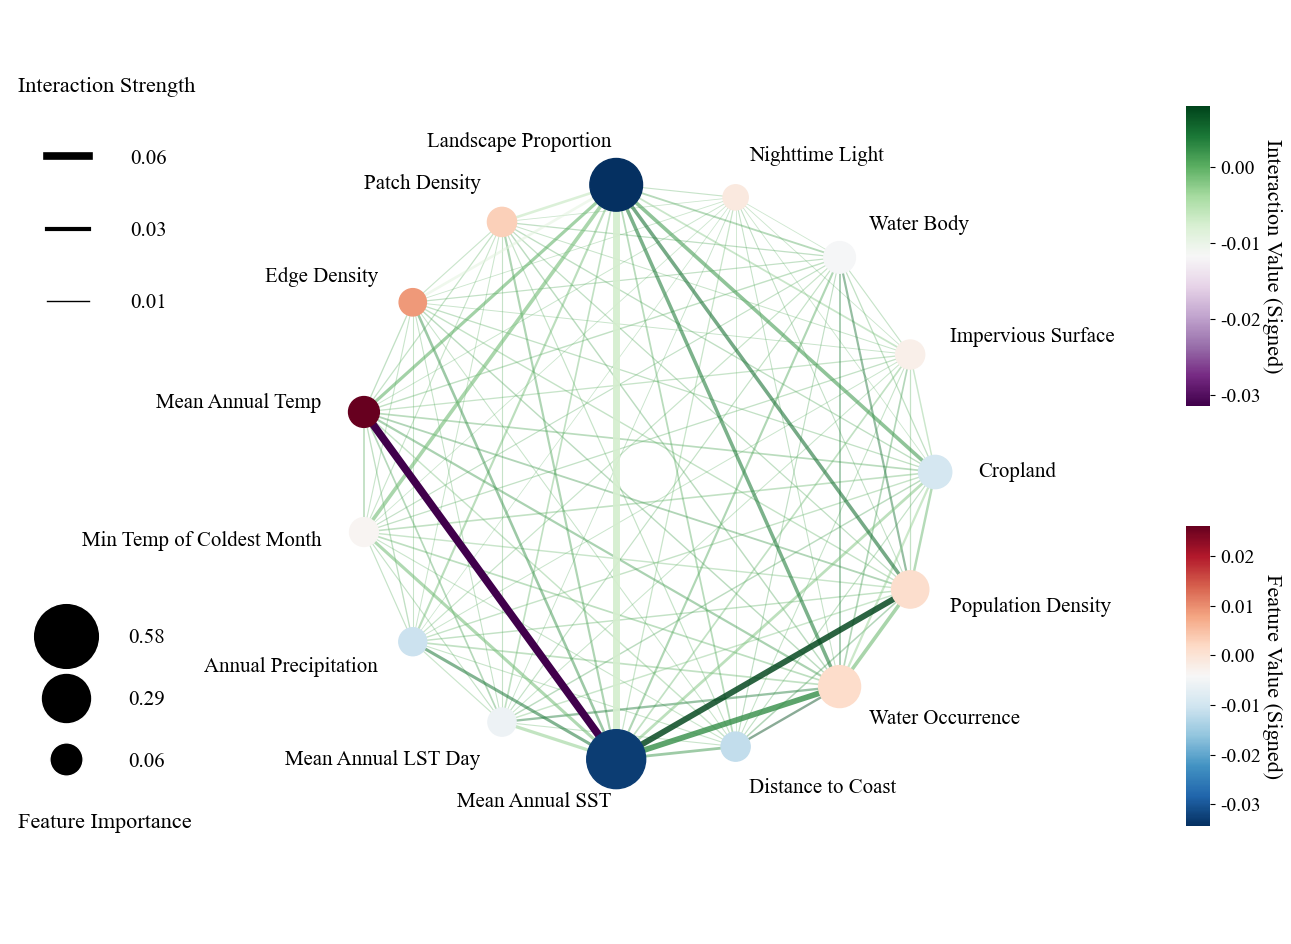

In [3]:
def plot_circular_interaction(features, importance_abs, importance_signed,
                              interaction_matrix_abs, interaction_matrix_signed):
    cmap_nodes = current_color_scheme['nodes']
    cmap_edges = current_color_scheme['edges']
    node_marker = current_style_scheme['marker']
    edge_linestyle = current_style_scheme['linestyle']
    
    # 获取显示用的特征名称
    display_features = [rename_dict.get(f, f) for f in features]
    
    fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={'aspect': 'equal'})
    
    n_features = len(features)
    G = nx.Graph()
    # 使用显示名称作为节点
    G.add_nodes_from(display_features)
    
    pos = nx.circular_layout(G)
    # 稍微增加标签距离，避免遮挡
    label_pos = {k: (v * 1.15) for k, v in pos.items()}
    
    # 颜色归一化
    norm_edges = mcolors.Normalize(vmin=interaction_matrix_signed.min(),
                                   vmax=interaction_matrix_signed.max())
    
    max_interaction_abs = np.max(interaction_matrix_abs)
    max_importance_abs = np.max(importance_abs)
    
    # 收集交互
    interactions = []
    for i in range(n_features):
        for j in range(i + 1, n_features):
            strength_abs = interaction_matrix_abs[i, j]
            strength_signed = interaction_matrix_signed[i, j]
            if strength_abs > 0:
                interactions.append((display_features[i], display_features[j], strength_abs, strength_signed))
    
    interactions.sort(key=lambda x: x[2])
    
    # 绘制边
    for u, v, strength_abs, strength_signed in interactions:
        color = cmap_edges(norm_edges(strength_signed))
        # 调整线条宽度范围，最大宽度从8减小到5，使其更精致
        width = 0.5 + (strength_abs / max_interaction_abs) * 5
        alpha = 0.3 + (strength_abs / max_interaction_abs) * 0.7
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=width,
                              edge_color=[color], style=edge_linestyle,
                              alpha=alpha, ax=ax)
    
    # 绘制节点
    norm_nodes = mcolors.Normalize(vmin=importance_signed.min(),
                                   vmax=importance_signed.max())
    
    node_colors = []
    node_sizes = []
    for i, feat in enumerate(features):
        imp_sign = importance_signed[i]
        imp_abs = importance_abs[i]
        node_colors.append(cmap_nodes(norm_nodes(imp_sign)))
        # 调整节点大小范围，增加基础大小，稍微减小最大增量
        node_sizes.append(300 + (imp_abs / max_importance_abs) * 1500)
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                          node_shape=node_marker, ax=ax)
    
    # 绘制标签
    for node, (x, y) in label_pos.items():
        ha = 'left' if x > 0 else 'right'
        # 增大字体
        plt.text(x, y, node, size=15, horizontalalignment=ha, verticalalignment='center')
    
    ax.axis('off')
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    #plt.title('SHAP Interaction Network - Mangrove Health Index', y=0.95, fontsize=16)
    
    # 线条粗细图例
    line_levels = [max_interaction_abs, max_interaction_abs * 0.5, max_interaction_abs * 0.1]
    line_labels = [f"{val:.2f}" for val in line_levels]
    legend_lines = [Line2D([0], [0], color='black', linewidth=0.5 + (val/max_interaction_abs)*5, linestyle=edge_linestyle) 
                   for val in line_levels]
    
    legend1 = ax.legend(legend_lines, line_labels, loc='center left',
                       bbox_to_anchor=(-0.2, 0.8),
                       title="Interaction Strength",
                       frameon=False, labelspacing=2.5 ,handletextpad=2,fontsize=15, title_fontsize=16)
    ax.add_artist(legend1)
    
    # 节点大小图例
    node_levels = [max_importance_abs, max_importance_abs * 0.5, max_importance_abs * 0.1]
    node_labels = [f"{val:.2f}" for val in node_levels]
    legend_nodes = []
    for val in node_levels:
        # 更新图例中节点大小计算公式以匹配绘图
        s = np.sqrt((300 + (val/max_importance_abs)*1500) / np.pi) * 2
        legend_nodes.append(Line2D([0], [0], marker=node_marker, color='w',
                                   markerfacecolor='black', markersize=s, linestyle='None'))
    
    leg = ax.legend(legend_nodes, node_labels, loc='center left',
             bbox_to_anchor=(-0.2, 0.22),
             title="Feature Importance",
             frameon=False, labelspacing=2, handletextpad=2,fontsize=15, title_fontsize=16)
    leg._legend_box.get_children().reverse()
    
    # 边颜色条
    cbar_edge_pos = [0.85, 0.55, 0.015, 0.25]
    cax_edge = fig.add_axes(cbar_edge_pos)
    sm_edge = plt.cm.ScalarMappable(cmap=cmap_edges, norm=norm_edges)
    sm_edge.set_array([])
    cbar_edge = plt.colorbar(sm_edge, cax=cax_edge)
    cbar_edge.set_label('Interaction Value (Signed)', rotation=270, labelpad=15, fontsize=16)
    cbar_edge.ax.tick_params(labelsize=14) 
    cbar_edge.outline.set_visible(False)
    
    # 节点颜色条
    cbar_node_pos = [0.85, 0.20, 0.015, 0.25]
    cax_node = fig.add_axes(cbar_node_pos)
    sm_node = plt.cm.ScalarMappable(cmap=cmap_nodes, norm=norm_nodes)
    sm_node.set_array([])
    cbar_node = plt.colorbar(sm_node, cax=cax_node)
    cbar_node.set_label('Feature Value (Signed)', rotation=270, labelpad=15, fontsize=16)
    cbar_node.ax.tick_params(labelsize=14) 
    cbar_node.outline.set_visible(False)
    
    # 保存
    save_path_png = f"rf_shap_interaction_style{style_index}_scheme{scheme_index}.png"
    plt.savefig(save_path_png, dpi=600, bbox_inches='tight')

    print(f"图像已保存至: {save_path_png}")
    plt.show()

plot_circular_interaction(independent_vars,
                             feature_importance_abs,
                             feature_importance_signed,
                             mean_interaction_matrix_abs,
                             mean_interaction_matrix_signed)